In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette('husl')

con = duckdb.connect('../data/processed/ecommerce.duckdb')
con.execute("""
    CREATE VIEW IF NOT EXISTS ecommerce_clean AS
    SELECT * FROM read_parquet('../data/processed/ecommerce_clean.parquet')
""")

print("Ready!")

Ready!


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

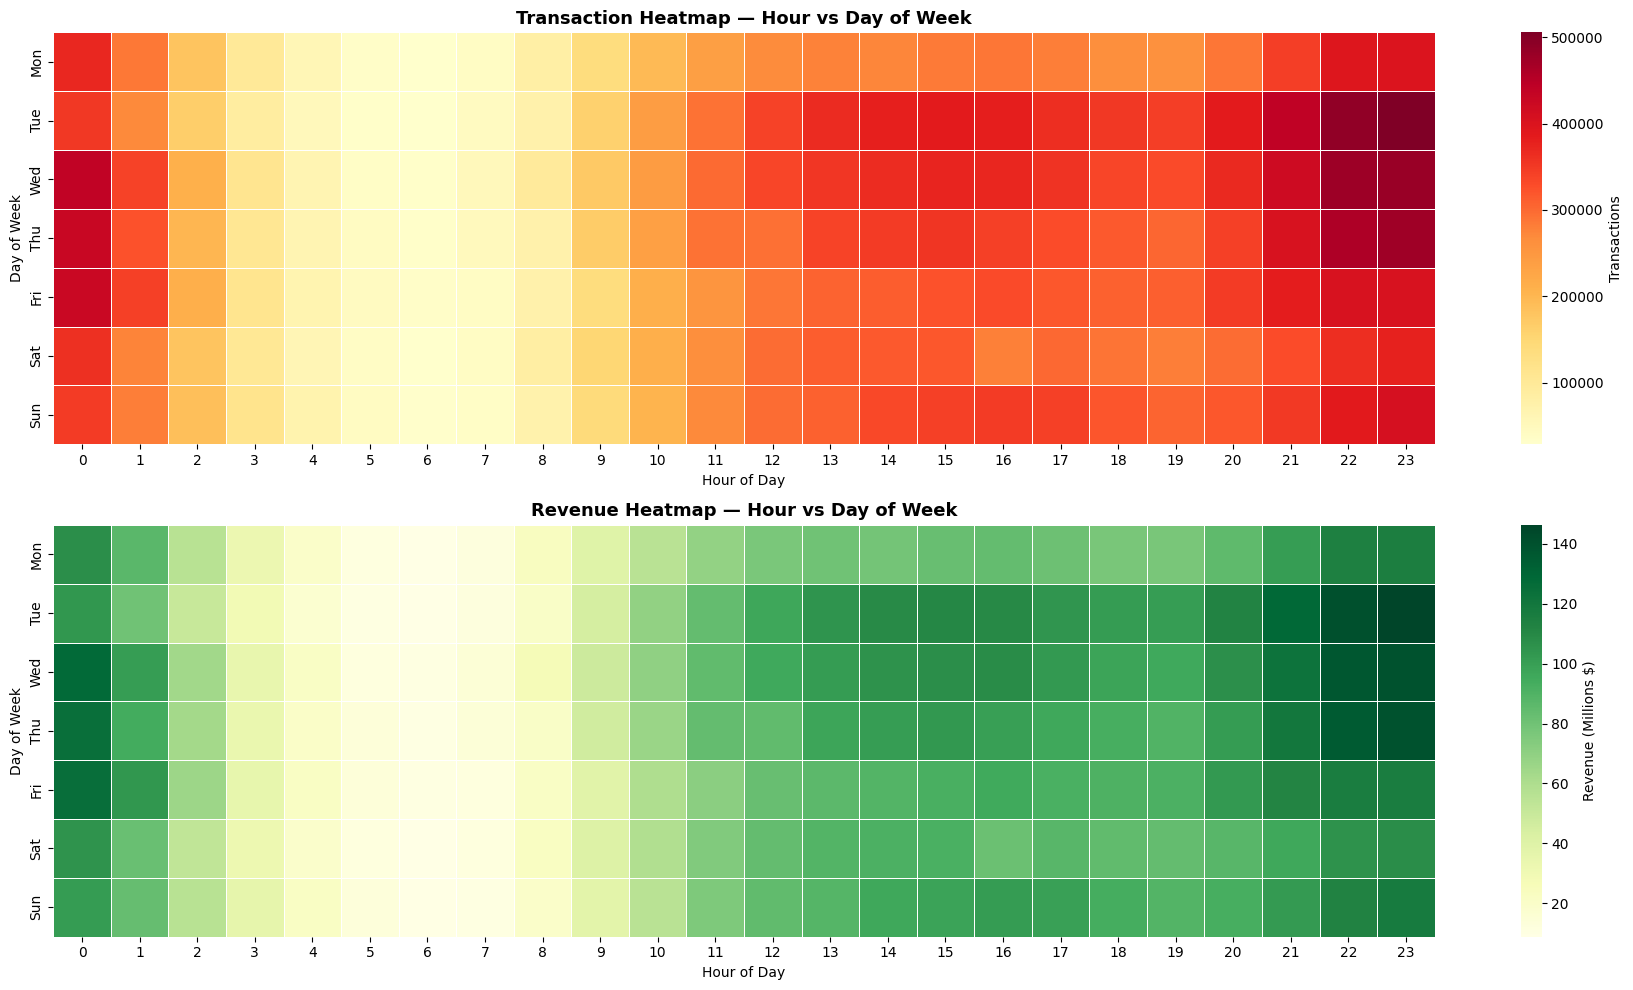

In [3]:
heatmap_data = con.execute("""
    SELECT
        day_of_week,
        hour_of_day,
        COUNT(*)                        AS total_transactions,
        ROUND(SUM(price)/1000000, 2)    AS revenue_millions
    FROM ecommerce_clean
    GROUP BY day_of_week, hour_of_day
    ORDER BY day_of_week, hour_of_day
""").df()

day_names = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
heatmap_data['day_name'] = heatmap_data['day_of_week'].apply(
    lambda x: day_names[int(x)]
)

# Pivot untuk heatmap
pivot_trx = heatmap_data.pivot(
    index='day_name',
    columns='hour_of_day',
    values='total_transactions'
)
pivot_rev = heatmap_data.pivot(
    index='day_name',
    columns='hour_of_day',
    values='revenue_millions'
)

# Reorder hari
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot_trx = pivot_trx.reindex(day_order)
pivot_rev = pivot_rev.reindex(day_order)

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Heatmap Transactions
sns.heatmap(pivot_trx, ax=axes[0],
            cmap='YlOrRd', fmt=',d',
            linewidths=0.5,
            cbar_kws={'label': 'Transactions'})
axes[0].set_title('Transaction Heatmap — Hour vs Day of Week',
                  fontweight='bold', fontsize=13)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Day of Week')

# Heatmap Revenue
sns.heatmap(pivot_rev, ax=axes[1],
            cmap='YlGn', fmt='.1f',
            linewidths=0.5,
            cbar_kws={'label': 'Revenue (Millions $)'})
axes[1].set_title('Revenue Heatmap — Hour vs Day of Week',
                  fontweight='bold', fontsize=13)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('../reports/figures/12_heatmap_hour_dow.png',
            dpi=150, bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

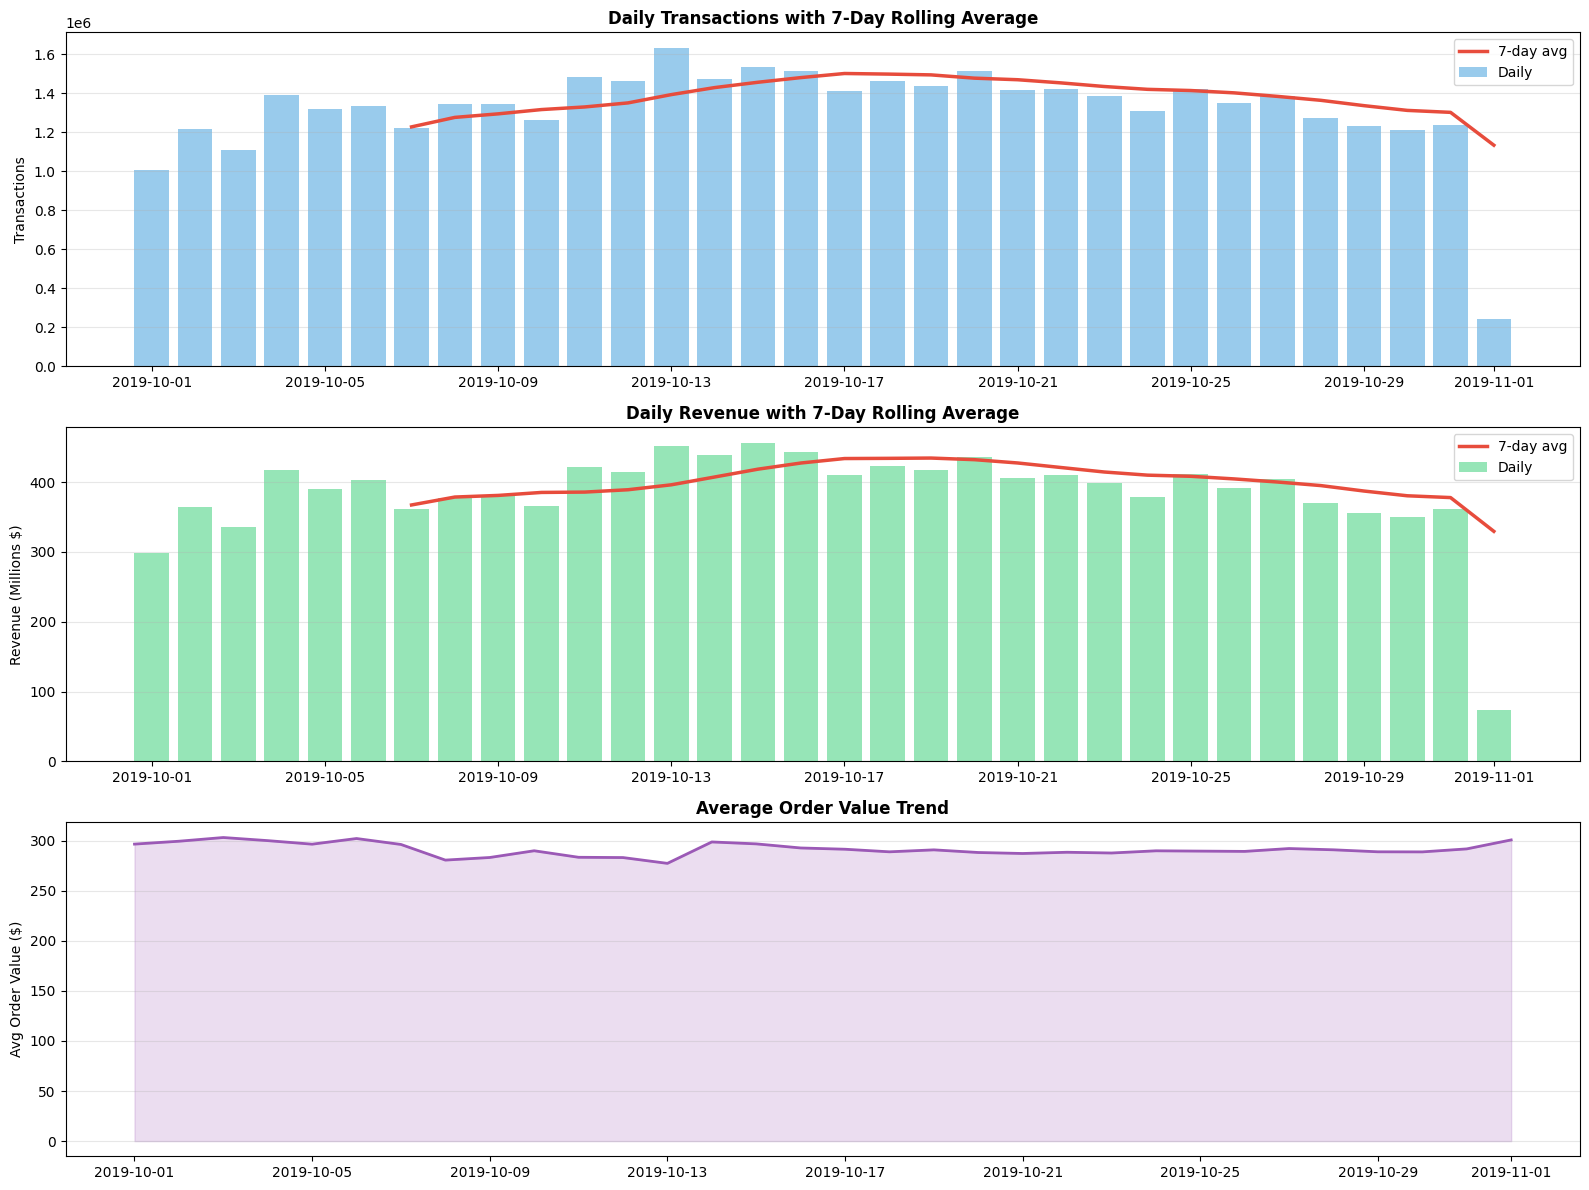

In [4]:
daily = con.execute("""
    SELECT
        event_date,
        COUNT(*)                        AS total_transactions,
        COUNT(DISTINCT user_id)         AS unique_users,
        ROUND(SUM(price)/1000000, 2)    AS revenue_millions,
        ROUND(AVG(price), 2)            AS avg_order_value
    FROM ecommerce_clean
    GROUP BY event_date
    ORDER BY event_date
""").df()

daily['event_date'] = pd.to_datetime(daily['event_date'])

# Rolling average 7 hari
daily['trx_7d_avg']  = daily['total_transactions'].rolling(7).mean()
daily['rev_7d_avg']  = daily['revenue_millions'].rolling(7).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Chart 1 — Transactions + Rolling avg
axes[0].bar(daily['event_date'], daily['total_transactions'],
            color='#3498db', alpha=0.5, label='Daily')
axes[0].plot(daily['event_date'], daily['trx_7d_avg'],
             color='#e74c3c', linewidth=2.5, label='7-day avg')
axes[0].set_title('Daily Transactions with 7-Day Rolling Average',
                  fontweight='bold')
axes[0].set_ylabel('Transactions')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Chart 2 — Revenue + Rolling avg
axes[1].bar(daily['event_date'], daily['revenue_millions'],
            color='#2ecc71', alpha=0.5, label='Daily')
axes[1].plot(daily['event_date'], daily['rev_7d_avg'],
             color='#e74c3c', linewidth=2.5, label='7-day avg')
axes[1].set_title('Daily Revenue with 7-Day Rolling Average',
                  fontweight='bold')
axes[1].set_ylabel('Revenue (Millions $)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Chart 3 — Avg Order Value trend
axes[2].plot(daily['event_date'], daily['avg_order_value'],
             color='#9b59b6', linewidth=2)
axes[2].fill_between(daily['event_date'],
                     daily['avg_order_value'],
                     alpha=0.2, color='#9b59b6')
axes[2].set_title('Average Order Value Trend', fontweight='bold')
axes[2].set_ylabel('Avg Order Value ($)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/13_daily_trend_rolling.png',
            dpi=150, bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

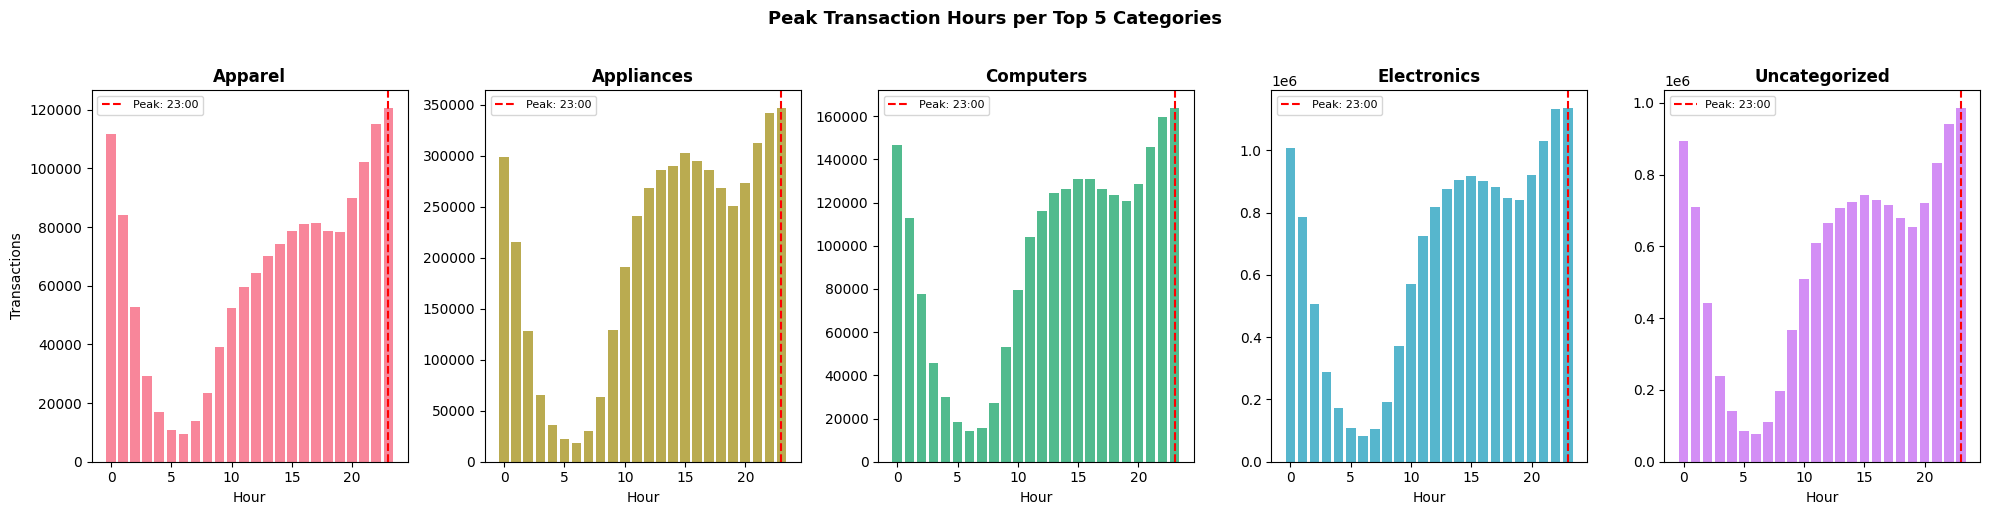

In [5]:
peak_hours = con.execute("""
    SELECT
        category_l1,
        hour_of_day,
        COUNT(*) AS total_transactions
    FROM ecommerce_clean
    WHERE category_l1 IN (
        SELECT category_l1
        FROM ecommerce_clean
        GROUP BY category_l1
        ORDER BY COUNT(*) DESC
        LIMIT 5
    )
    GROUP BY category_l1, hour_of_day
    ORDER BY category_l1, hour_of_day
""").df()

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)
categories = peak_hours['category_l1'].unique()
colors     = sns.color_palette('husl', 5)

for i, (cat, color) in enumerate(zip(categories, colors)):
    data = peak_hours[peak_hours['category_l1'] == cat]
    axes[i].bar(data['hour_of_day'],
                data['total_transactions'],
                color=color, alpha=0.85)
    
    # Highlight peak hour
    peak_hour = data.loc[data['total_transactions'].idxmax(), 'hour_of_day']
    axes[i].axvline(peak_hour, color='red',
                    linestyle='--', linewidth=1.5,
                    label=f'Peak: {peak_hour:02d}:00')
    
    axes[i].set_title(cat.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Hour')
    axes[i].legend(fontsize=8)
    if i == 0:
        axes[i].set_ylabel('Transactions')

plt.suptitle('Peak Transaction Hours per Top 5 Categories',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/14_peak_hours_category.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Identifikasi slot waktu terbaik untuk flash sale
flash_sale = con.execute("""
    SELECT
        day_of_week,
        hour_of_day,
        COUNT(*)                        AS total_transactions,
        ROUND(SUM(price)/1000000, 2)    AS revenue_millions,
        COUNT(DISTINCT user_id)         AS unique_users,
        ROUND(AVG(price), 2)            AS avg_order_value
    FROM ecommerce_clean
    GROUP BY day_of_week, hour_of_day
    ORDER BY total_transactions DESC
    LIMIT 20
""").df()

day_names = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
flash_sale['day_name'] = flash_sale['day_of_week'].apply(
    lambda x: day_names[int(x)]
)

print("=" * 60)
print("     TOP 10 OPTIMAL FLASH SALE SLOTS")
print("=" * 60)
print(f"\n{'Rank':<5} {'Day':<10} {'Hour':<8} {'Transactions':>13} {'Revenue':>12}")
print("-" * 55)

for i, row in flash_sale.head(10).iterrows():
    rank = flash_sale.index.get_loc(i) + 1
    print(f"{rank:<5} {row['day_name']:<10} "
          f"{int(row['hour_of_day']):02d}:00    "
          f"{row['total_transactions']:>13,} "
          f"  ${row['revenue_millions']:>8.1f}M")

print("=" * 60)
print("\nBusiness Recommendation:")
print("   Schedule flash sales during top slots above")
print("   for maximum reach and conversion potential.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     TOP 10 OPTIMAL FLASH SALE SLOTS

Rank  Day        Hour      Transactions      Revenue
-------------------------------------------------------
1     Tue        23:00          505,797   $   146.4M
2     Tue        22:00          488,386   $   140.9M
3     Wed        23:00          480,952   $   139.7M
4     Wed        22:00          477,239   $   137.5M
5     Thu        23:00          474,612   $   139.8M
6     Thu        22:00          459,421   $   135.2M
7     Tue        21:00          440,768   $   128.2M
8     Wed        00:00          440,114   $   127.7M
9     Thu        00:00          428,601   $   124.5M
10    Fri        00:00          426,703   $   125.0M

Business Recommendation:
   Schedule flash sales during top slots above
   for maximum reach and conversion potential.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

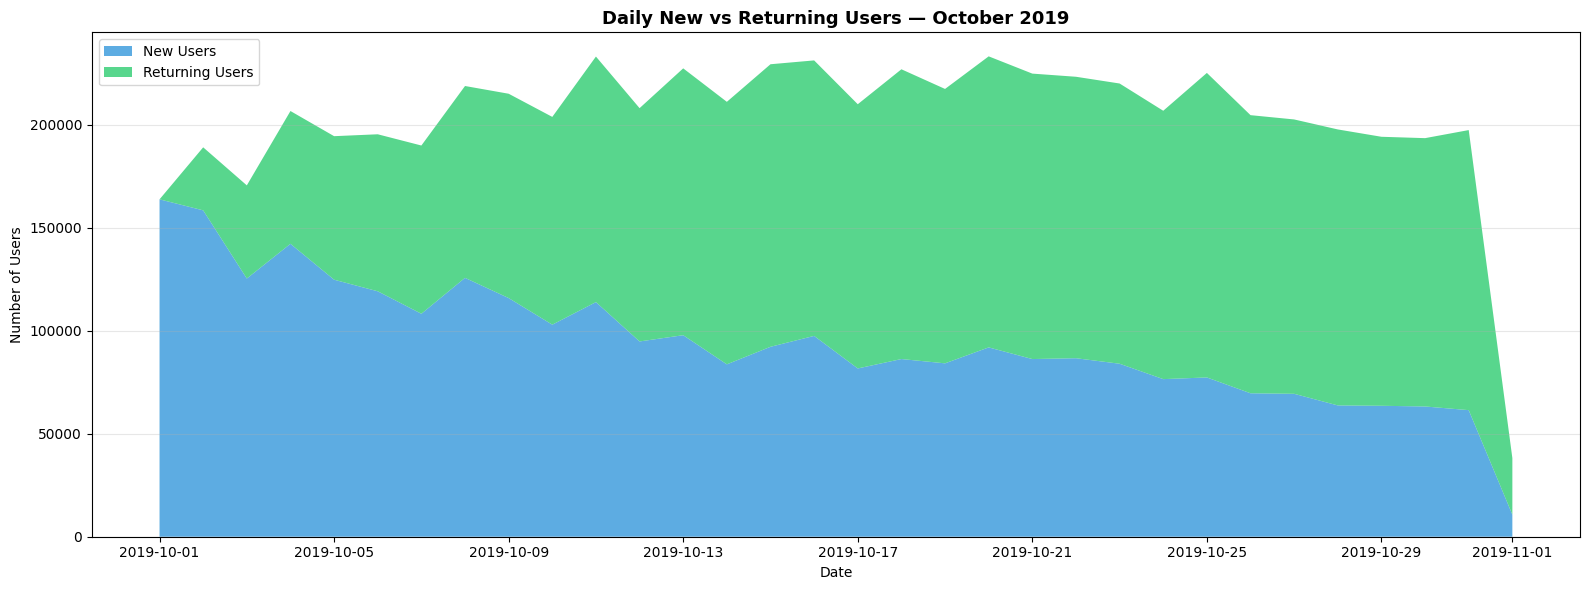


User Activity Summary:
   New Users       : 3,021,435 (46.5%)
   Returning Users : 3,479,054 (53.5%)


In [7]:
user_pattern = con.execute("""
    WITH user_first_purchase AS (
        SELECT
            user_id,
            MIN(event_date) AS first_purchase_date
        FROM ecommerce_clean
        GROUP BY user_id
    )
    SELECT
        DATE(e.event_time)                      AS event_date,
        COUNT(DISTINCT CASE
            WHEN e.event_date = u.first_purchase_date
            THEN e.user_id END)                 AS new_users,
        COUNT(DISTINCT CASE
            WHEN e.event_date > u.first_purchase_date
            THEN e.user_id END)                 AS returning_users
    FROM ecommerce_clean e
    JOIN user_first_purchase u ON e.user_id = u.user_id
    GROUP BY DATE(e.event_time)
    ORDER BY event_date
""").df()

user_pattern['event_date'] = pd.to_datetime(user_pattern['event_date'])

fig, ax = plt.subplots(figsize=(16, 6))

ax.stackplot(user_pattern['event_date'],
             user_pattern['new_users'],
             user_pattern['returning_users'],
             labels=['New Users', 'Returning Users'],
             colors=['#3498db', '#2ecc71'],
             alpha=0.8)

ax.set_title('Daily New vs Returning Users — October 2019',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Users')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/15_new_vs_returning.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
total_new       = user_pattern['new_users'].sum()
total_returning = user_pattern['returning_users'].sum()
total           = total_new + total_returning

print(f"\nUser Activity Summary:")
print(f"   New Users       : {total_new:,} ({total_new/total*100:.1f}%)")
print(f"   Returning Users : {total_returning:,} ({total_returning/total*100:.1f}%)")

In [8]:
con.close()
print("Time Pattern Analysis selesai!")
print("\nCharts saved:")
print("   12_heatmap_hour_dow.png")
print("   13_daily_trend_rolling.png")
print("   14_peak_hours_category.png")
print("   15_new_vs_returning.png")

Time Pattern Analysis selesai!

Charts saved:
   12_heatmap_hour_dow.png
   13_daily_trend_rolling.png
   14_peak_hours_category.png
   15_new_vs_returning.png
